In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from keras.layers import Input,Lambda,Dense,Flatten,Conv2D,MaxPooling2D
from keras.models import Model,Sequential
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [ ]:
image_size=[224,224]
train_path = '/content/drive/MyDrive/PNEUMONIA_DETECTION/D2/train'
test_path = '/content/drive/MyDrive/PNEUMONIA_DETECTION/D2/test'
val_path = '/content/drive/MyDrive/PNEUMONIA_DETECTION/D2/val'

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(train_path, target_size = (224,224), batch_size = 32,
                                             class_mode = 'categorical')
test_data = test_datagen.flow_from_directory(test_path, target_size=(224,224), batch_size = 32,
                                           class_mode = 'categorical')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# VGG16 model
vgg = VGG16(input_shape = image_size+[3], weights='imagenet', include_top = False)

58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
# As all the layers are trained already
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
# Add additional layers
x = Flatten()(vgg.output)
x = Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

# Create the model
model = Model(inputs=vgg.input, outputs=prediction)
model.summary()

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = 'accuracy')

In [ ]:
r = model.fit(train_data, validation_data = test_data, epochs = 10)

Epoch 1/5
163/163 [==============================] - 4443s 27s/step - loss: 0.2076 - accuracy: 0.9189 - val_loss: 0.2423 - val_accuracy: 0.9087
Epoch 2/5
163/163 [==============================] - 4314s 26s/step - loss: 0.1068 - accuracy: 0.9605 - val_loss: 0.2344 - val_accuracy: 0.9215
Epoch 3/5
163/163 [==============================] - 4360s 27s/step - loss: 0.0978 - accuracy: 0.9655 - val_loss: 0.2731 - val_accuracy: 0.8910
Epoch 4/5
163/163 [==============================] - 4304s 26s/step - loss: 0.1058 - accuracy: 0.9594 - val_loss: 0.4154 - val_accuracy: 0.8926
Epoch 5/5
163/163 [==============================] - 4369s 27s/step - loss: 0.0972 - accuracy: 0.9651 - val_loss: 0.3739 - val_accuracy: 0.9038


In [ ]:
train_accuracy = model.evaluate(train_data)[1]
test_accuracy = model.evaluate(test_data)[1]
print('Accuracy of VGG16')
print('Train Accuracy: ',train_accuracy,'\nTest Accuracy: ',test_accuracy)

20/20 [==============================] - 442s 22s/step - loss: 0.3739 - accuracy: 0.9038
Accuracy of VGG16
Train Accuracy:  0.9781441688537598 
Test Accuracy:  0.9038461446762085


In [ ]:
# Get predictions on test data
y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = test_data.classes

# Calculate the confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
cr = classification_report(y_true, y_pred)

print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(cr)

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_pred_prob = model.predict(test_data)
fpr, tpr, thresholds = roc_curve(test_data.classes, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Enter the path of the image: /content/drive/MyDrive/PNEUMONIA_DETECTION/Data2/val/opacity/person1398_bacteria_3548.jpeg


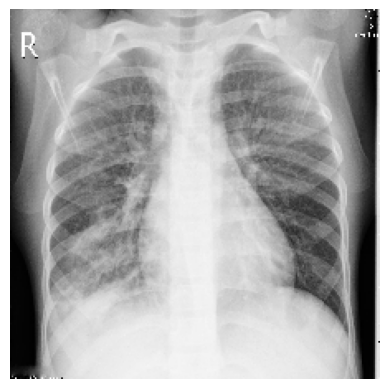

1/1 [==============================] - 1s 973ms/step
The Chest X-ray image is showing signs of Pneumonia.


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Get user input for the image path
user_image_path = input("Enter the path of the image: ")

# Load the user input image
user_img = image.load_img(user_image_path, target_size=(224, 224))

# Display the input image
plt.imshow(user_img)
plt.axis('off')
plt.show()

# Convert the image to an array and expand dimensions to match VGG16 input shape
user_img_array = image.img_to_array(user_img)
user_img_array = np.expand_dims(user_img_array, axis=0)

# Preprocess the image for VGG16 model
user_img_processed = preprocess_input(user_img_array)

# Make prediction using the VGG16 model
prediction = model.predict(user_img_processed)
predicted_class_index = np.argmax(prediction)
class_labels = train_data.class_indices

# Display the prediction result in the desired format
for class_label, index in class_labels.items():
    if index == predicted_class_index:
        if class_label == 'NORMAL':
            print("The Chest X-ray image is normal.")
        else:
            print("The Chest X-ray image is showing signs of Pneumonia.")
        break
